<a href="https://colab.research.google.com/github/hayamwahdan/data-storytelling-presentation/blob/main/Telecom_Customer_Churn_Strategic_Analysis_%26_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Analysis Report
## Objective:
To identify the key factors contributing to customer attrition (churn) and provide actionable insights for the retention team.

## Workflow:
1. Data Loading & Initial Exploration.
2. Data Cleaning & Type Conversion.
3. Exploratory Data Analysis (EDA) & Visualizations.
4. Business Insights & Recommendations.

In [1]:
# Import essential libraries for data science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Set plot style for professional look
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the dataset using the specific path in Colab environment
file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn - WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

# Display first 5 rows to understand the structure
print("Dataset loaded. Shape:", df.shape)
df.head()

Dataset loaded. Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# 1. Remove customerID - it's a unique identifier with no predictive power
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 2. Fix TotalCharges column
# Convert to numeric, turning empty spaces into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Handle Missing Values
# Dropping the 11 rows where TotalCharges was null
df.dropna(inplace=True)

# 4. Simplify Categorical Labels
# Consolidate "No internet/phone service" into "No" for easier visualization
cols_to_simplify = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_simplify:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Verify cleaning results
print("Cleaning complete. New Shape:", df.shape)

Cleaning complete. New Shape: (7032, 20)


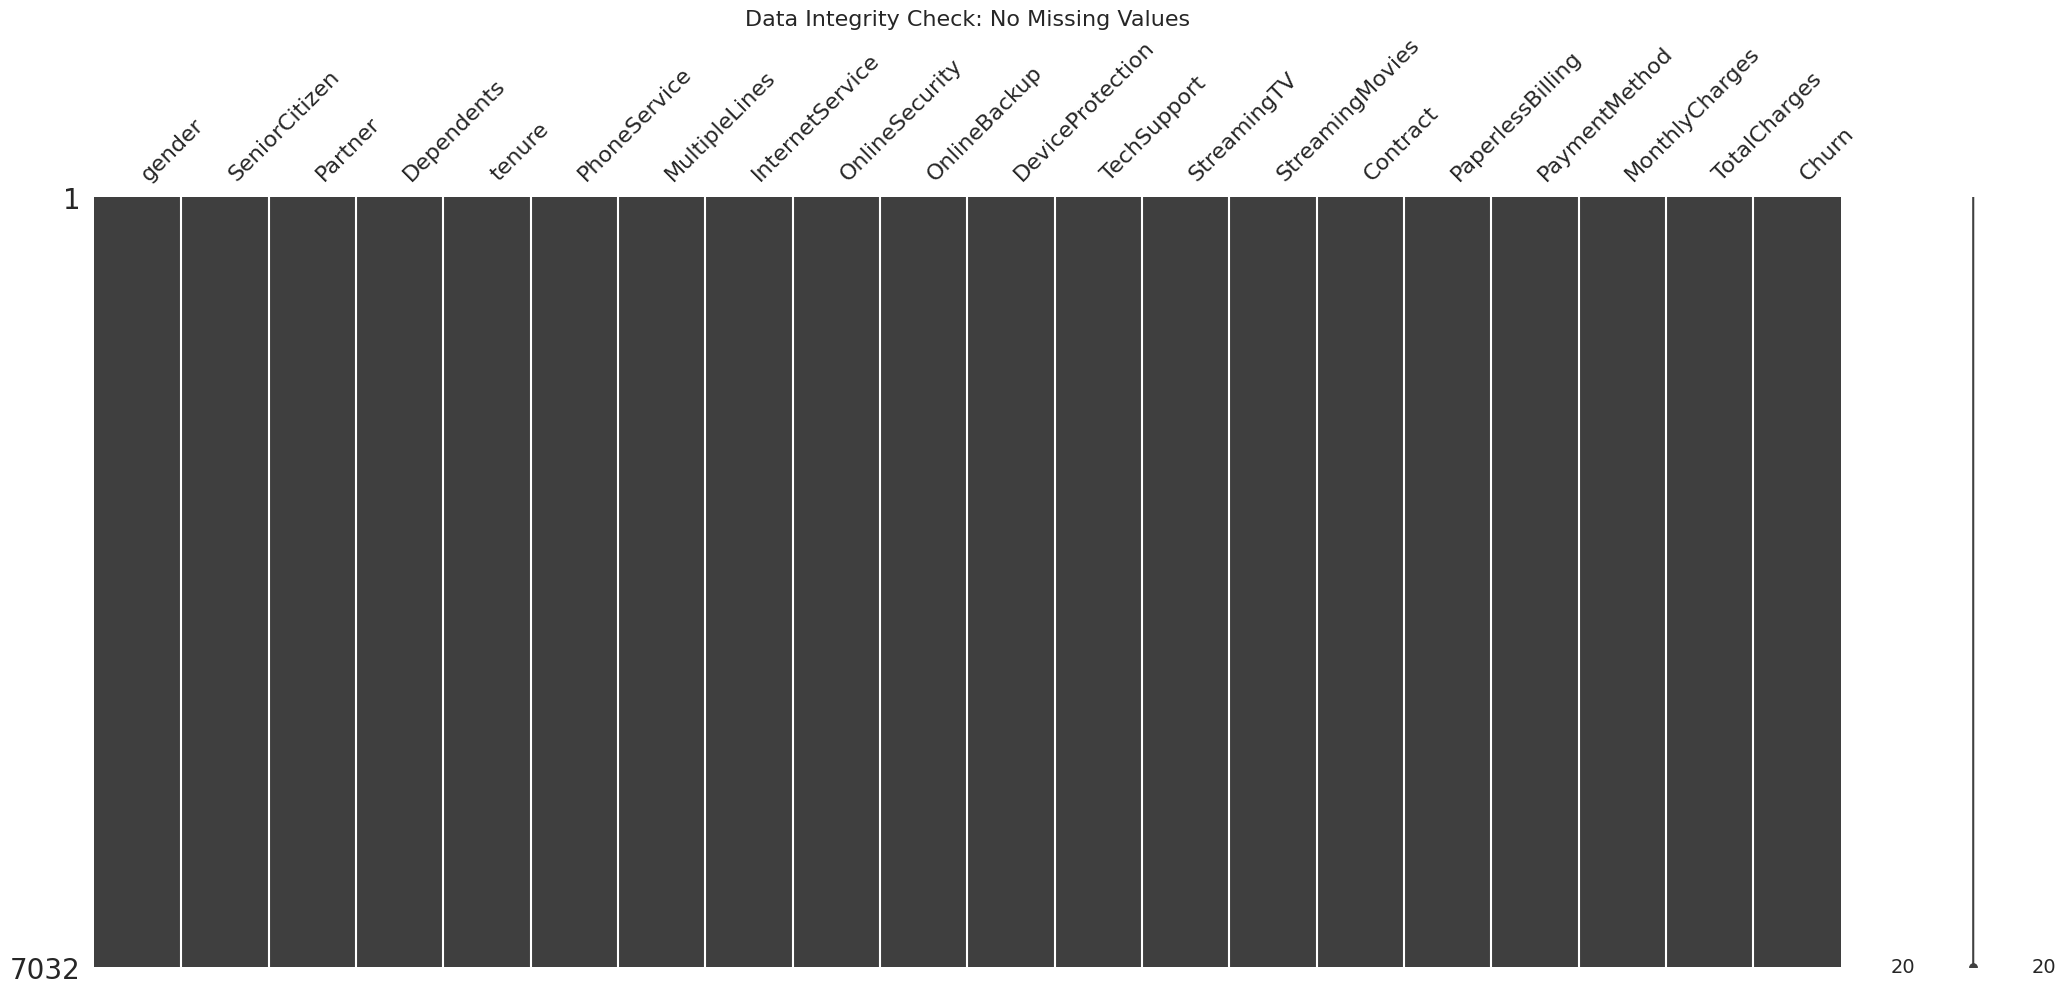

In [4]:
# Visualize missing values to confirm zero NaNs
msno.matrix(df)
plt.title('Data Integrity Check: No Missing Values', fontsize=16)
plt.show()

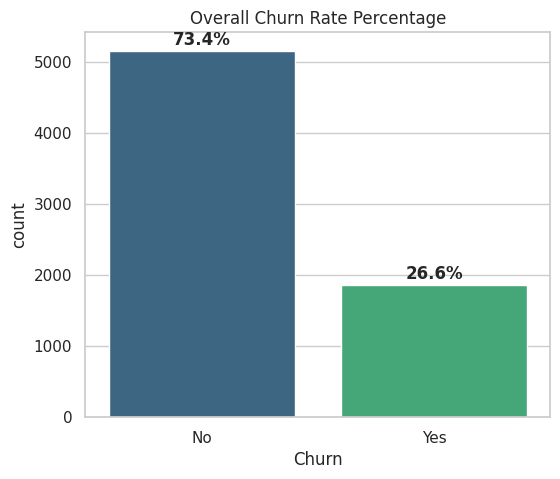

In [5]:
# Visualize Churn distribution
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)

# Add percentages on top of bars
total = len(df['Churn'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%\n'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='center', fontweight='bold')

plt.title('Overall Churn Rate Percentage')
plt.show()

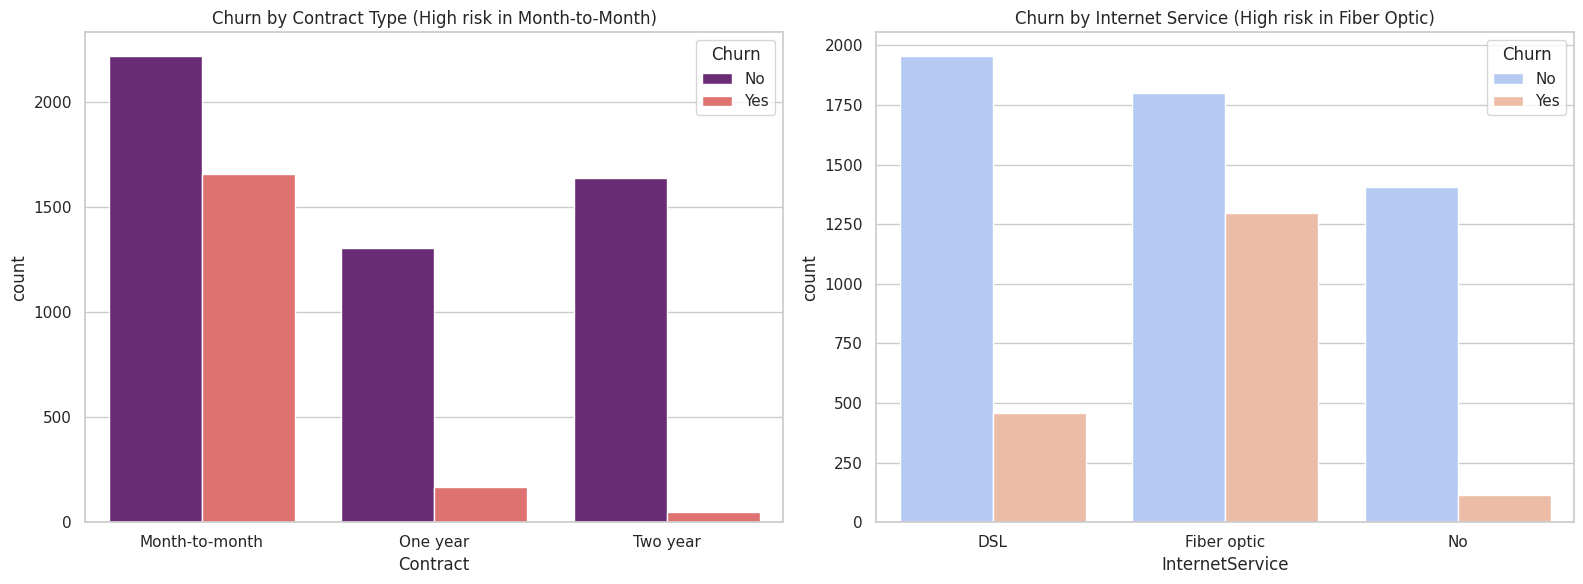

In [6]:
# Set up a grid for multiple categorical plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Churn by Contract Type
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0], palette='magma')
axes[0].set_title('Churn by Contract Type (High risk in Month-to-Month)')

# Plot 2: Churn by Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Churn by Internet Service (High risk in Fiber Optic)')

plt.tight_layout()
plt.show()

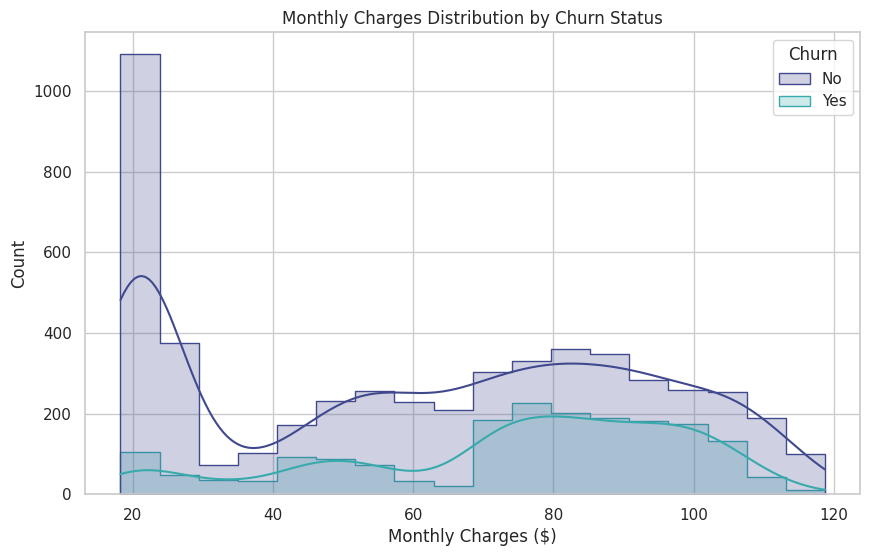

In [7]:
# Distribution of Monthly Charges for Churn vs Non-Churn
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, element="step", palette='mako')
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Monthly Charges ($)')
plt.show()

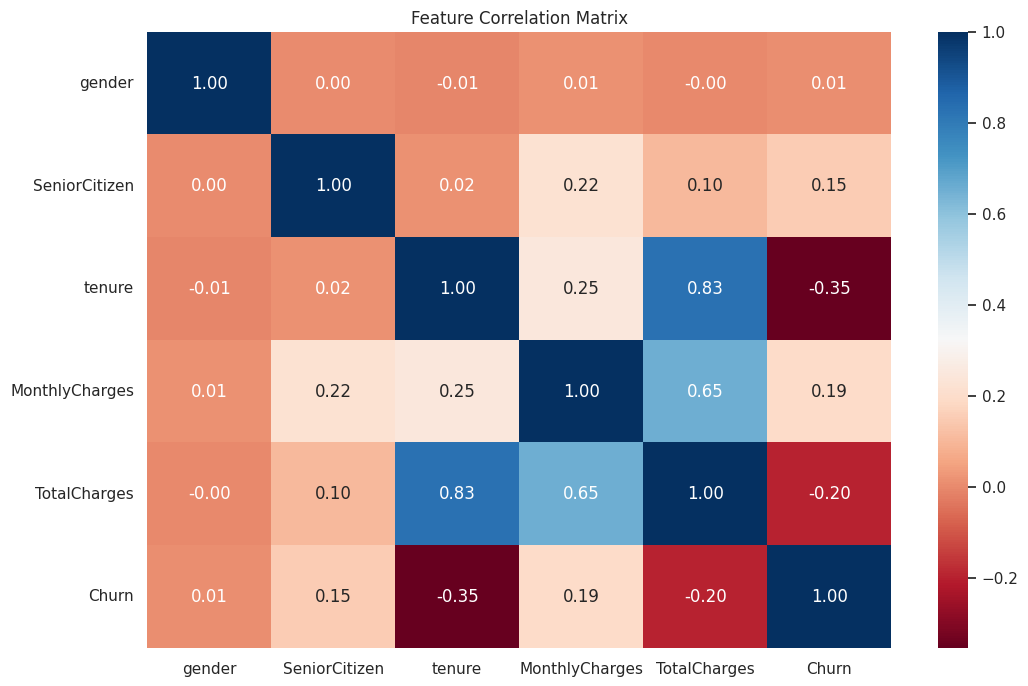

In [8]:
# Convert Churn and Gender to binary for correlation analysis
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})
df_corr['gender'] = df_corr['gender'].map({'Female': 1, 'Male': 0})

# Plot heatmap for numerical columns
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

## Executive Summary of Insights:
1. **Contract Strategy:** Month-to-month contracts have a massive churn rate. Converting these to 1-year contracts could significantly reduce loss.
2. **Fiber Optic Issue:** Customers with Fiber Optic services are leaving at a higher rate despite paying more. This suggests possible service quality issues or price dissatisfaction.
3. **Early Churn:** There is a high concentration of churn during the first 6 months (Low Tenure).
4. **Payment Friction:** Electronic checks are associated with higher churn compared to automated bank transfers or credit cards.

## Recommendations:
* Offer a discount for the first 12 months for new customers to increase tenure.
* Investigate technical issues with Fiber Optic infrastructure.
* Incentivize customers to switch from "Electronic Check" to "Automatic Billing".